# 01 EDA: what does delivery demand look like? (Casablanca)

**Data note:** semi-synthetic. Real weather and calendar, simulated orders and couriers. Not company data.

Goal: read the series by eye before modelling: trend, daily and weekly seasonality, and the effects of rain, Ramadan and payday.

In [1]:
import sys
sys.path.insert(0, '../src')
import pandas as pd
import matplotlib.pyplot as plt
from config import DATA_NOTE

plt.rcParams.update({'figure.dpi': 100, 'axes.spines.top': False, 'axes.spines.right': False})

def label(fig):
    fig.tight_layout(rect=[0, 0.04, 1, 1])
    fig.text(0.01, 0.01, DATA_NOTE, fontsize=8, color='gray')

df = pd.read_parquet('../data/processed/demand_casablanca.parquet')
df['date'] = df['timestamp'].dt.tz_localize(None).dt.normalize()
df['raining'] = df['precipitation'] > 0.5
df.head()

,timestamp,timestamp_utc,orders,couriers_online,temperature_2m,precipitation,rain,hour,dow,is_holiday,is_ramadan,is_payday_window,date,raining
0,2024-10-01 01:00:00+01:00,2024-10-01 00:00:00+00:00,38,15,19.7,0.0,0.0,1,1,False,False,False,2024-10-01,False
1,2024-10-01 02:00:00+01:00,2024-10-01 01:00:00+00:00,28,12,20.4,0.0,0.0,2,1,False,False,False,2024-10-01,False
2,2024-10-01 03:00:00+01:00,2024-10-01 02:00:00+00:00,28,16,20.8,0.0,0.0,3,1,False,False,False,2024-10-01,False
3,2024-10-01 04:00:00+01:00,2024-10-01 03:00:00+00:00,29,14,20.9,0.0,0.0,4,1,False,False,False,2024-10-01,False
4,2024-10-01 05:00:00+01:00,2024-10-01 04:00:00+00:00,37,9,20.9,0.0,0.0,5,1,False,False,False,2024-10-01,False


## 1. Daily orders over time
Trend plus weekly wiggle. Also look for anything odd: dips, bumps, steps.

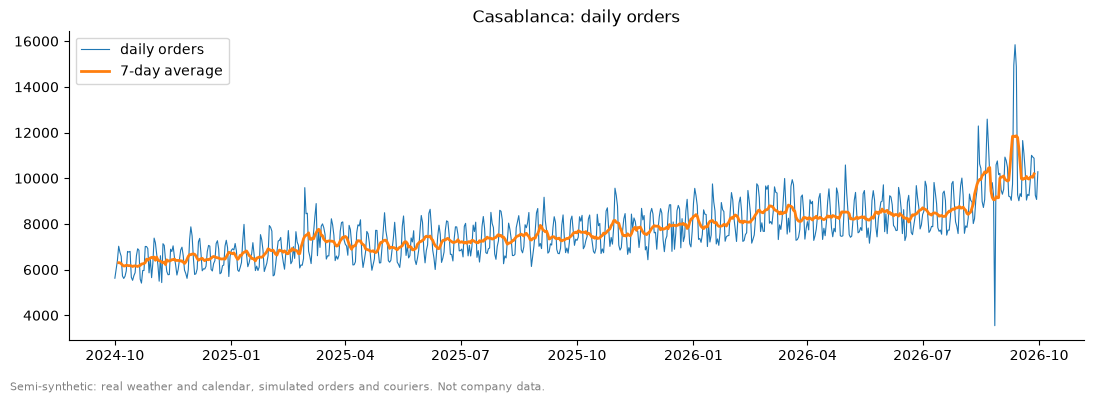

(date
 2026-08-27    3547
 2024-10-22    5410
 2024-11-07    5433
 Name: orders, dtype: int64,
 date
 2026-09-13    14873
 2026-09-11    14948
 2026-09-12    15844
 Name: orders, dtype: int64)

In [2]:
daily = df.groupby('date')['orders'].sum()
fig, ax = plt.subplots(figsize=(11, 4))
ax.plot(daily.index, daily.values, lw=0.8, label='daily orders')
ax.plot(daily.index, daily.rolling(7, center=True).mean(), lw=2, label='7-day average')
ax.set_title('Casablanca: daily orders'); ax.legend(); label(fig)
plt.show()
daily.sort_values().head(3), daily.sort_values().tail(3)

**Takeaway:** a steady upward trend (growth) with a weekly rhythm. Ramadan (Mar 2025, Feb-Mar 2026) does not dip the daily total; it nudges it up, so the totals hide a big change in the hourly shape (see chart 5). Near the end there are oddities (a one-day crash, a few unusually high days, a step up) that no calendar or weather feature explains. We will come back to them in the miss investigation, not now.

## 2. Hour x weekday heatmap
When do people order?

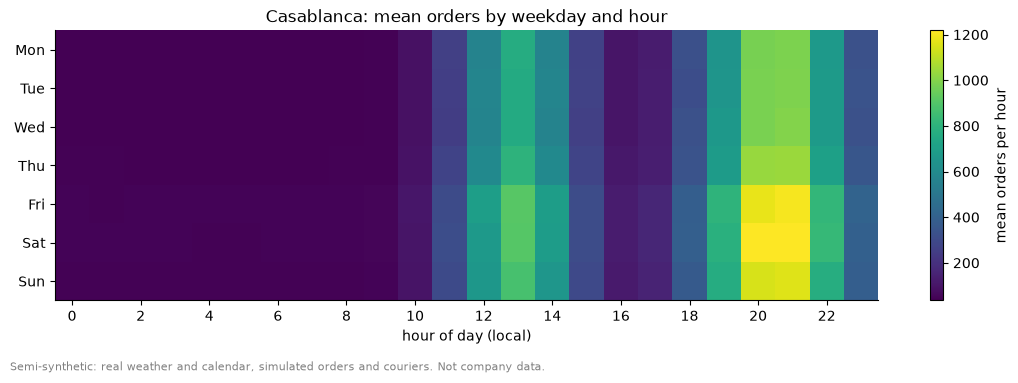

In [3]:
heat = df.pivot_table(index='dow', columns='hour', values='orders', aggfunc='mean')
fig, ax = plt.subplots(figsize=(11, 3.8))
im = ax.imshow(heat.values, aspect='auto', cmap='viridis')
ax.set_yticks(range(7)); ax.set_yticklabels(['Mon','Tue','Wed','Thu','Fri','Sat','Sun'])
ax.set_xticks(range(0, 24, 2)); ax.set_xlabel('hour of day (local)')
fig.colorbar(im, label='mean orders per hour'); ax.set_title('Casablanca: mean orders by weekday and hour'); label(fig)
plt.show()

**Takeaway:** two peaks (lunch about 13:00, dinner about 20:30-21:00), near-silent nights, and Friday to Sunday stronger. Hour and weekday are the backbone of any model.

## 3. Rain vs no rain
Same hour of day, rainy hours vs dry hours (non-holiday, non-Ramadan, before the end-of-period oddities).

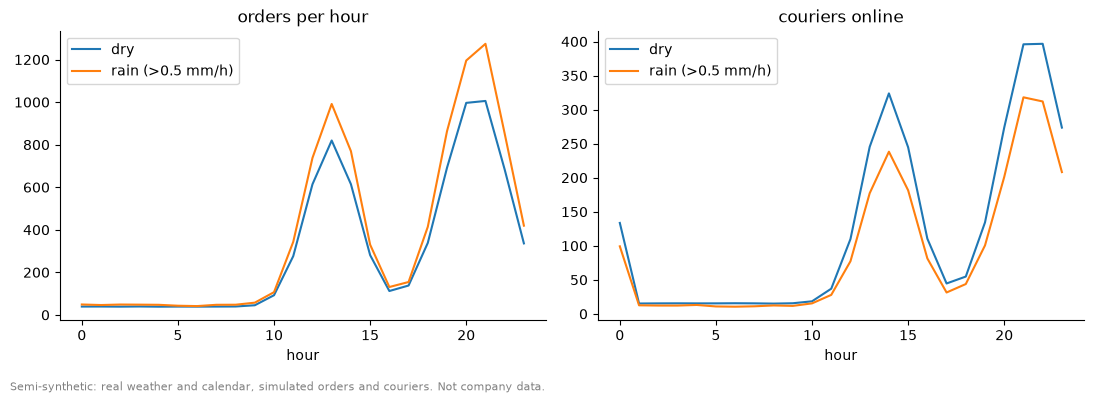

([1.2, 1.21, 1.25, 1.18, 1.17, 1.12, 1.22, 1.25, 1.2, 1.27, 1.25],
 [0.7, 0.72, 0.74, 0.74, 0.74, 0.7, 0.8, 0.75, 0.73, 0.8, 0.79])

In [4]:
base = df[(~df.is_ramadan) & (~df.is_holiday) & (df.timestamp < '2026-08-01')]
g = base.groupby(['hour', 'raining'])[['orders', 'couriers_online']].mean().unstack()
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, col, title in zip(axes, ['orders', 'couriers_online'], ['orders per hour', 'couriers online']):
    ax.plot(g[col][False], label='dry'); ax.plot(g[col][True], label='rain (>0.5 mm/h)')
    ax.set_title(title); ax.set_xlabel('hour'); ax.legend()
label(fig); plt.show()
(g['orders'][True] / g['orders'][False]).loc[12:22].round(2).tolist(), (g['couriers_online'][True] / g['couriers_online'][False]).loc[12:22].round(2).tolist()

**Takeaway:** in rain, orders go up by roughly a fifth and couriers online go down by roughly a quarter, at every hour. This is the supply/demand squeeze that makes rain the key driver to forecast.

## 4. Courier supply vs demand
Orders per online courier: a proxy for how stretched the fleet is.

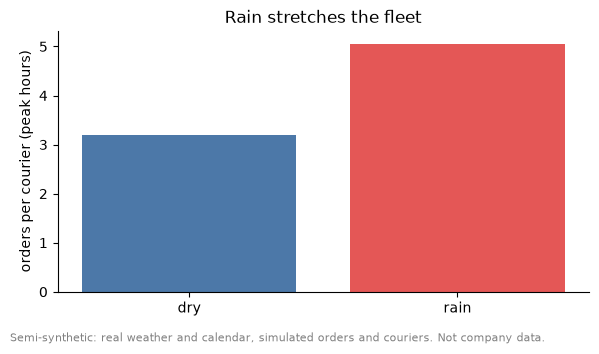

,mean,50%
raining,,
False,3.191963,2.918552
True,5.058974,4.283473


In [5]:
peak = df[df.hour.isin([12, 13, 14, 20, 21, 22]) & (df.couriers_online > 0)].copy()
peak['orders_per_courier'] = peak['orders'] / peak['couriers_online']
r = peak.groupby('raining')['orders_per_courier'].describe()[['mean', '50%']]
fig, ax = plt.subplots(figsize=(6, 3.5))
ax.bar(['dry', 'rain'], r['mean'], color=['#4c78a8', '#e45756'])
ax.set_ylabel('orders per courier (peak hours)'); ax.set_title('Rain stretches the fleet'); label(fig)
plt.show(); r

**Takeaway:** each courier carries about 1.6x as many orders in rain at peak hours (more demand, fewer couriers). Under-forecasting rain means slower deliveries; this is where the ops decision (rider incentives) comes from.

## 5. Ramadan vs normal days
Share of each day's orders by hour, so overall growth does not mask the shape change.

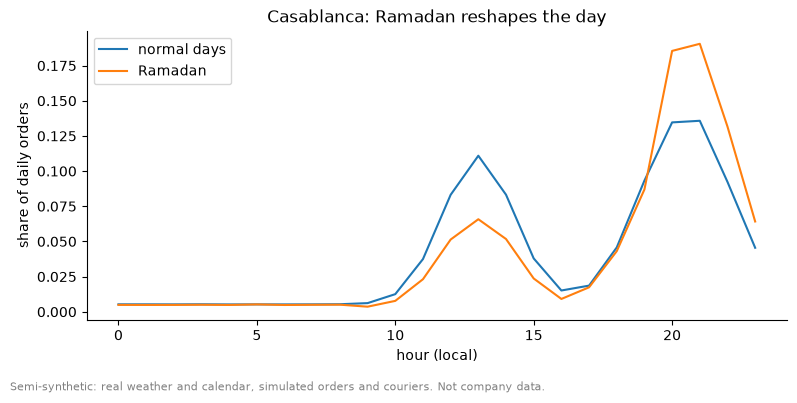

In [6]:
d = df[~df.is_holiday].copy()
d['share'] = d['orders'] / d.groupby('date')['orders'].transform('sum')
s = d.groupby(['hour', 'is_ramadan'])['share'].mean().unstack()
fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(s[False], label='normal days'); ax.plot(s[True], label='Ramadan')
ax.set_xlabel('hour (local)'); ax.set_ylabel('share of daily orders'); ax.legend()
ax.set_title('Casablanca: Ramadan reshapes the day'); label(fig)
plt.show()

**Takeaway:** in Ramadan the lunch peak shrinks and demand moves to the post-iftar evening. The response is to reshape courier shifts, not just add more couriers.

## 6. Payday effect
Daily orders divided by their centred 28-day average (removes trend), averaged by day of month.

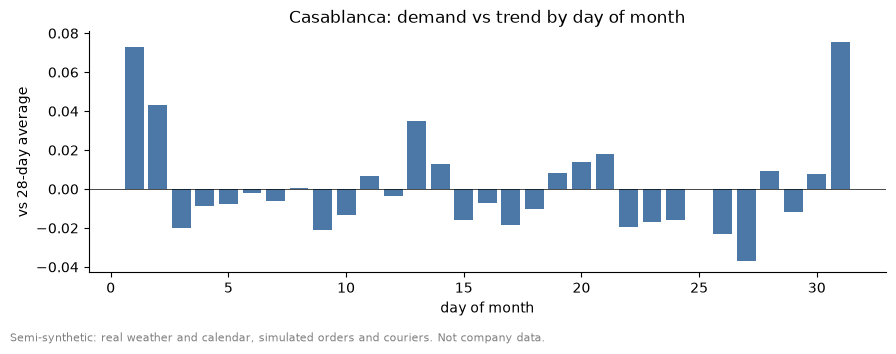

In [7]:
trend = daily.rolling(28, center=True).mean()
ratio = (daily / trend).dropna()
by_dom = ratio.groupby(ratio.index.day).mean()
fig, ax = plt.subplots(figsize=(9, 3.5))
ax.bar(by_dom.index, by_dom.values - 1, color='#4c78a8')
ax.axhline(0, color='k', lw=0.5); ax.set_xlabel('day of month'); ax.set_ylabel('vs 28-day average')
ax.set_title('Casablanca: demand vs trend by day of month'); label(fig)
plt.show()

**Takeaway:** a small lift (roughly 4-8%) around the month turn (days 31, 1 and 2), the payday window; the rest of the month is noise of about +/-2%. It is smaller than the rain or Ramadan effects, so a model needs the payday flag. Weekday patterns also leak into this view, which is why the other days wobble.